#INFORMACIÓN GENERAL


UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO

INGENIERÍA INFORMÁTICA Y DE SISTEMAS

INTELIGENCIA ARTIFICIAL

LABORATORIO 03: BÚSQUEDA EN LA SOLUCIÓN DE PROBLEMAS

**Parte 1: Búsqueda soluciones básico**

#BÚSQUEDA DE SOLUCIONES - ALGORITMO BÁSICO


Primero se implementan las clases requeridas para búsqueda de soluciones.

En la sección de la implementación de la aplicación, se verifica el correcto funcionamiento de las clases.

##Clases de un motor de búsqueda de soluciones

###Clase Acción

In [3]:
#Clase Acción
class Accion:
  def __init__(self, nombre):
    self.nombre = nombre

  def __str__(self):
    return self.nombre

###Clase Estado

In [4]:
#Clase Estado
class Estado:
  def __init__(self, nombre, acciones):
    self.nombre = nombre
    self.acciones = acciones

  def __str__(self):
    return self.nombre

###Clase Problema

In [5]:
#Clase Problema.
class Problema:
  def __init__(self, estado_inicial, estados_objetivos, acciones):
    self.estado_inicial = estado_inicial
    self.estados_objetivos = estados_objetivos
    self.acciones = acciones

  def __str__(self):
    msg = "Estado Inicial: {0} -> Objetivos: {1}"
    return msg.format(self.estado_inicial.nombre,self.estados_objetivos)

  # -- Determina si se alcanzó el objetivo
  def es_objetivo(self, estado):
    return estado in self.estados_objetivos

  # -- Determina el estado al que se llega desde el estado actual en base a la acción
  def resultado(self, estado, accion):
    # -- Verificar si el estado actual es parte del problema
    if estado.nombre not in self.acciones.keys():
      return None
    # -- Recuperar diccionario de posibles acciones que se pueden realizar del estado actual
    acciones_estado = self.acciones[estado.nombre]
    # -- Verificar si la acción a realizar conduce o no a un nuevo estado
    if accion.nombre not in acciones_estado.keys():
      return None
    # -- Recupera y devuelve el nuevo estado alcanzado después de ejecutar la acción
    return acciones_estado[accion.nombre]

###Clase Nodo

In [6]:
#Clase Nodo
class Nodo:
  def __init__(self, estado, accion=None, acciones=None, padre=None):
    self.estado = estado # -- Estado al que corresponde el nodo
    self.accion = accion # -- Acción mediante la cuál se llegó a este nodo
    self.acciones = acciones # -- Acciones posibles a realizar a partir de este nodo para llegar a los hijos
    self.padre = padre
    self.hijos = [] # -- Lista de nodos hijo (objetos) del nodo actual

  def __str__(self):
    return self.estado.nombre

  # Método para expandir el nodo a los nodos hijo
  # -- Devuelve una lista de nodos hijo del nodo actual
  def expandir(self, problema):
    # -- Inicializar lista de nodos hijo
    self.hijos = []
    # -- Validar si el estado actual está o no en el contexto del problema
    if not self.acciones:
      if self.estado.nombre not in problema.acciones.keys():
        return self.hijos
      self.acciones = problema.acciones[self.estado.nombre]
    # -- El objetivo es crear los nodos hijo en función a las acciones que se pueden realizar
    for accion in self.acciones.keys():
      # -- Determinar mediante que acción se crea el nodo hijo
      accion_hijo = Accion(accion)
      # -- Determinar a que nuevo estado corresponde el nodo hijo
      nuevo_estado = problema.resultado(self.estado, accion_hijo)
      # -- Determinar el diccionario de acciones que puede realizar el nodo hijo
      acciones_nuevo = {}
      if nuevo_estado.nombre in problema.acciones.keys():
        acciones_nuevo = problema.acciones[nuevo_estado.nombre]
      # -- Crea el nodo hijo con los parámetros previamente determinados
      #    Considerar que el último parámetro hace referencia al padre del nodo hijo
      hijo = Nodo(nuevo_estado, accion_hijo, acciones_nuevo, self)
      # -- Agregar nodo hijo creado a la lista de nodos hijo del nodo actual
      self.hijos.append(hijo)
    # -- Devuelve la lista de nodos hijo
    return self.hijos



##Aplicación: Viajes en ciudades
  

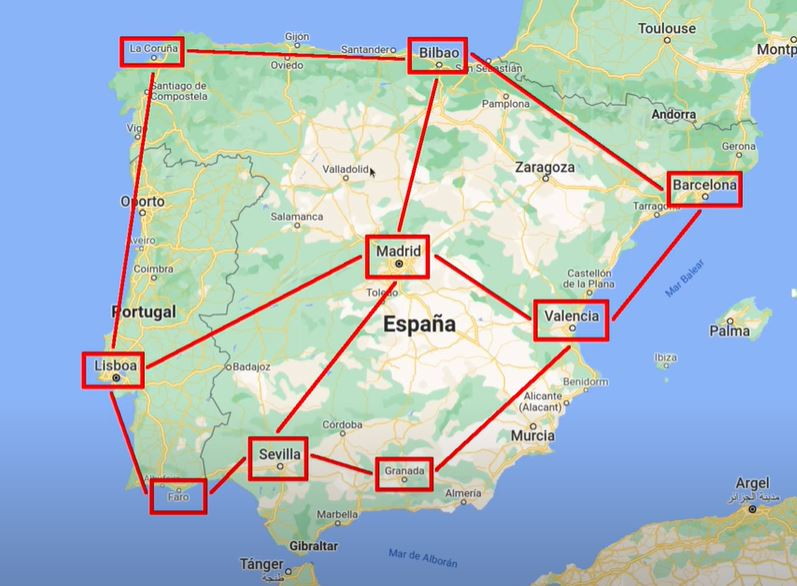

### Clase ViajesCiudades


In [7]:
#Clase ViajesCiudades
class ViajesCiudades:

  def __init__(self):
    # -- Nombre de la clase
    self.nombre = 'Viajes por ciudades'

    # -- Definición de acciones
    accN = Accion('norte')
    accS = Accion('sur')
    accE = Accion('este')
    accO = Accion('oeste')

    # -- Definción de estados
    coruna = Estado('La Coruña',[accS, accE])
    bilbao = Estado('Bilbao',[accS, accE, accO])
    barcelona = Estado('Barcelona',[accS, accO])
    lisboa = Estado('Lisboa',[accN, accS, accE])
    madrid = Estado('Madrid',[accN, accS, accE, accO])
    valencia = Estado('Valencia',[accN, accS, accO])
    faro = Estado('Faro',[accN, accE, accO])
    sevilla = Estado('Sevilla',[accN, accE, accO])
    granada = Estado('Granada',[accN, accO])

    # -- Definición de viajes
    viajes = {'La Coruña':{'sur':lisboa,
                          'este':bilbao},
              'Bilbao':{'sur':madrid,
                        'oeste':barcelona,
                        'este':coruna},
              'Barcelona':{ 'sur':valencia,
                            'oeste':bilbao},
              'Lisboa':{'norte':coruna,
                        'sur':faro,
                        'este':madrid},
              'Madrid':{'norte':bilbao,
                        'sur':sevilla,
                        'este':valencia,
                        'oeste':lisboa},
              'Valencia':{'norte':barcelona,
                          'sur':granada,
                          'oeste':madrid},
              'Faro':{'norte':lisboa,
                      'este':sevilla},
              'Sevilla':{ 'norte':madrid,
                          'este':granada,
                          'oeste':faro},
              'Granada':{ 'norte':valencia,
                          'oeste':sevilla}}

    # -- Definir el atributo lista de estados en el contexto del problema
    self.estados = [coruna, bilbao, barcelona, lisboa, madrid, valencia, faro, sevilla, granada]
    # -- Definir el atributo de los posibles viajes de una ciudad a otras
    self.viajes = viajes

  def __str__(self):
    return self.nombre

  def DeterminarRuta(self):
    # -- Solicitar ciudad inicial y ciudad destino
    ciudad_inicial = input('Ingrese ciudad de partida: ')
    ciudad_destino = input('Ingrese ciudad de destino: ')
    # -- Generar estado_inicial y estados objetivo
    estado_inicial = [e for e in self.estados if e.nombre == ciudad_inicial][0]
    estados_objetivo = [e for e in self.estados if e.nombre == ciudad_destino]
    # -- Instanciar la clase Problema
    problema = Problema(estado_inicial, estados_objetivo, self.viajes)
    # -- Crear nodo (raiz) para el estado incial
    nodo_raiz = Nodo(estado_inicial, None, problema.acciones[estado_inicial.nombre], None)
    nodo_actual = nodo_raiz
    # -- Efectuar recorrido desde ciudad inicial hasta ciudad destino
    estado_actual = estado_inicial
    objetivo_alcanzado = problema.es_objetivo(estado_actual)
    while not objetivo_alcanzado:
      # -- Recuperar las acciones que se pueden ejecutar desde el estado actual
      # acciones_posibles = problema.acciones[estado_actual.nombre]
      # -- Recuperar las ciudades a las que se puede ir
      hijos_actual = nodo_actual.expandir(problema)
      # -- Mostrar las posibles ciudades
      print('Desde ',estado_actual.nombre, 'se puede llegar a las siguientes ciudades')
      print({hijo.accion.nombre:hijo.estado.nombre for hijo in hijos_actual})
      # -- Elegir nueva ruta
      accion = input('Ingrese que acción desea efectuar: ')
      # -- Determinar nueva ciudad a la que se llega con la ruta elegida
      estado_actual = [hijo.estado for hijo in hijos_actual if accion == hijo.accion.nombre][0]
      # -- Verificar si se alcanzó el objetivo
      objetivo_alcanzado = problema.es_objetivo(estado_actual)
      # -- Mostrar a la ciudad a la que se llegó con la ruta elegida
      if not objetivo_alcanzado:
        print('Ud. llegó a la ciudad de ', estado_actual.nombre)
        # -- Recuperar nodo del estado_actual
        nodo_actual = [nodo for nodo in nodo_actual.hijos if nodo.estado.nombre == estado_actual.nombre][0]
    # -- Mostrar mensaje que ya se alcanzó la ciudad objetivo
    print('Ud. alcanzó su objetivo, ya está en ', estado_actual.nombre)


###Programa principal

In [ ]:

# -- Crear una instancia de la clase de viajes de ciudades
viaje_ciudades = ViajesCiudades()
# -- Determinar rutas
viaje_ciudades.DeterminarRuta()


Desde  Lisboa se puede llegar a las siguientes ciudades
{'norte': 'La Coruña', 'sur': 'Faro', 'este': 'Madrid'}
Ud. llegó a la ciudad de  La Coruña
Desde  La Coruña se puede llegar a las siguientes ciudades
{'sur': 'Lisboa', 'este': 'Bilbao'}
